Доступные столбцы: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
Автоматически выбраны: параметр='age', цель='survived'


/tmp/ipykernel_61841/1688155852.py:121: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  violin_parts = ax.violinplot(local_data, positions=[i], vert=False,
/tmp/ipykernel_61841/1688155852.py:144: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  boxplots = ax.boxplot(local_data, positions=[i + shift_in_units], widths=0.1,
/tmp/ipykernel_61841/1688155852.py:121: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  violin_parts = ax.violinplot(local_data, positions=[i], vert=False,
/tmp/ipykernel_61841/1688155852.py:144: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} i

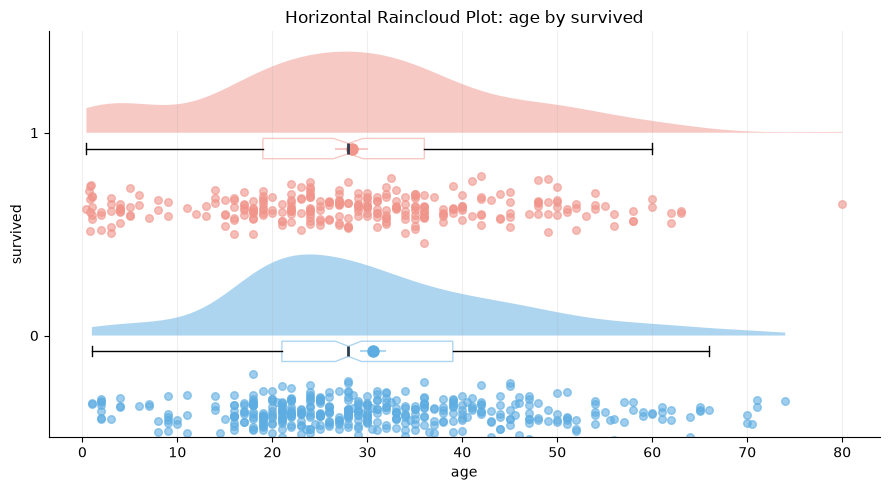

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.axes as mpl_axes
import scipy.stats
from typing import Tuple, Optional, Any

# ==============================================================================
# Класс Plotter: Управление фигурами и осями Matplotlib
# ==============================================================================

class Plotter:
    def __init__(self, nrows: int = 1, ncols: int = 1, figsize: Tuple[int, int] = (6, 6)) -> None:
        # --------------------------------------------------------
        # Инициализация фигуры и массива осей
        # --------------------------------------------------------
        self.fig, self.axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
        self.nrows = nrows
        self.ncols = ncols
        
        if nrows == 1 and ncols == 1:
            self.axes = np.array([self.axes])
        elif nrows == 1 or ncols == 1:
            self.axes = self.axes.reshape(-1)
        else:
            self.axes = self.axes.flatten()

        self.position = None
    
    def __getitem__(self, index: int):
        return self._get_axes_by_index(index)
    
    def __getattr__(self, name: str):
        if hasattr(mpl_axes.Axes, name):
            def dynamic_method(*args, 
                             idx: Optional[int] = None,
                             irow: Optional[int] = None,
                             icol: Optional[int] = None,
                             **kwargs):
                ax = self._get_axis(idx, irow, icol) if self.position is None else self.position
                method = getattr(ax, name)
                return method(*args, **kwargs)
            
            return dynamic_method
        
        raise AttributeError(f"'{type(self).__name__}' object has no attribute '{name}'")
    
    def _get_axes_by_index(self, idx: int = 0) -> Any:
        return self.axes[idx]
    
    def _get_axes_by_coords(self, irow: int = 0, icol: int = 0) -> Any:
        idx = irow * self.ncols + icol
        return self.axes[idx]

    def _get_axis(self,
                  idx: Optional[int] = None,
                  irow: Optional[int] = None,
                  icol: Optional[int] = None) -> Any:
        if idx is not None:
            return self._get_axes_by_index(idx)
        elif irow is not None and icol is not None:
            return self._get_axes_by_coords(irow, icol)
        else:
            return self.axes[0]
    
    def set_position(self,
                     idx: Optional[int] = None,
                     irow: Optional[int] = None,
                     icol: Optional[int] = None) -> None:
        self.position = self._get_axis(idx, irow, icol)
    
    def del_position(self) -> None:
        self.position = None
        
    def labels(self,
               xlabel: str,
               ylabel: str,
               title: str,
               idx: Optional[int] = None,
               irow: Optional[int] = None,
               icol: Optional[int] = None) -> Any:
        ax = self._get_axis(idx, irow, icol) if self.position is None else self.position
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        return ax

    def raincloud_plot(self, data, param_name, target_col_name, classes, colors,
                       idx: Optional[int] = None,
                       irow: Optional[int] = None,
                       icol: Optional[int] = None,
                       violin_width: float = 0.8,
                       violin_alpha: float = 0.5,
                       points_size: int = 30,
                       points_alpha: float = 0.6,
                       box_alpha: float = 0.5,
                       median_width: int = 2,
                       pixel_shift_y: float = -15) -> Any:
        
        ax = self._get_axis(idx, irow, icol) if self.position is None else self.position
        
        # --------------------------------------------------------
        # Вычисление сдвига в координатах данных на основе пикселей
        # --------------------------------------------------------
        ax.set_ylim(-0.5, len(classes) - 0.5)
        bbox = ax.get_window_extent()
        y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
        pixels_per_unit = bbox.height / y_range
        shift_in_units = pixel_shift_y / pixels_per_unit
        
        # --------------------------------------------------------
        # Шаг 1. Построение элементов raincloud plot для каждого класса
        # --------------------------------------------------------
        for i, group in enumerate(classes):
            local_data = data[data[target_col_name] == group][param_name]
            
            if len(local_data) == 0:
                continue
                
            # 1.1. Violin plot (якорный элемент, остается на исходной позиции i)
            violin_parts = ax.violinplot(local_data, positions=[i], vert=False,
                                         showextrema=False, showmedians=False, widths=violin_width)
                    
            for pc in violin_parts['bodies']:
                pc.set_facecolor(colors[i % len(colors)])
                pc.set_alpha(violin_alpha)
                vertices = pc.get_paths()[0].vertices
                vertices[:, 1] = np.clip(vertices[:, 1], i, np.inf)

            # 1.2. Jitter (точки) со сдвигом вниз
            y_points = np.random.normal(i + shift_in_units - 0.3, 0.06, len(local_data))
            ax.scatter(local_data, y_points, alpha=points_alpha, s=points_size, 
                       color=colors[i % len(colors)])
            
            # 1.3. Доверительный интервал (размах) со сдвигом вниз
            mean = np.mean(local_data)
            sem = scipy.stats.sem(local_data)
            ci_low, ci_high = scipy.stats.t.interval(0.95, len(local_data) - 1, loc=mean, scale=sem)
            
            ax.errorbar(mean, i + shift_in_units, xerr=[[mean-ci_low], [ci_high-mean]], 
                        fmt='o', color=colors[i % len(colors)], markersize=8)

            # 1.4. Boxplot со сдвигом вниз
            boxplots = ax.boxplot(local_data, positions=[i + shift_in_units], widths=0.1, 
                                  notch=True, patch_artist=True, showfliers=False, vert=False)

            for box in boxplots['boxes']:
                box.set_facecolor('white')
                box.set_alpha(box_alpha)
                box.set_edgecolor(colors[i % len(colors)])
            for median in boxplots['medians']:
                median.set_color('#2C3E50')
                median.set_linewidth(median_width)
        
        # --------------------------------------------------------
        # Шаг 2. Настройка визуального стиля (UpSet style)
        # --------------------------------------------------------
        ax.set_yticks(np.arange(len(classes)))
        ax.set_yticklabels(classes)
        ax.set_xlabel(param_name)
        ax.set_ylabel(target_col_name)
        ax.set_title(f'Horizontal Raincloud Plot: {param_name} by {target_col_name}')
        
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis='x', alpha=0.20)
        
        return ax

    def tight_layout(self) -> None:
        self.fig.tight_layout()
    
    def save(self, path: str, dpi: int = 300, **kwargs) -> None:
        self.fig.savefig(path, dpi=dpi, **kwargs)
    
    def show(self) -> None:
        plt.show()


# ==============================================================================
# Шаг 1. Загрузка и очистка данных
# ==============================================================================

file_path = "/home/julia/code/NSU_AI-Robotics/tsr/archive/Titanic.csv"
df = pd.read_csv(file_path)

df = df.loc[:, ~df.columns.str.contains('^Unnamed')]


# ==============================================================================
# Шаг 2. Интеллектуальный выбор столбцов (регистронезависимый)
# ==============================================================================

cols_lower = {col.lower(): col for col in df.columns}

numeric_cols = df.select_dtypes(include='number').columns.tolist()
param_name = cols_lower.get('age', cols_lower.get('fare', numeric_cols[0] if numeric_cols else df.columns[0]))

categorical_cols = df.select_dtypes(exclude='number').columns.tolist()
target_col_name = cols_lower.get('survived', cols_lower.get('sex', cols_lower.get('class', categorical_cols[0] if categorical_cols else df.columns[0])))

print(f"Доступные столбцы: {df.columns.tolist()}")
print(f"Автоматически выбраны: параметр='{param_name}', цель='{target_col_name}'")

df_clean = df.dropna(subset=[param_name, target_col_name]).copy()


# ==============================================================================
# Шаг 3. Определение цветовой палитры и классов
# ==============================================================================

primary_color = "#5DADE2"   # Прозрачно-голубой (прозрачность задается через alpha)
secondary_color = "#F1948A" # Прозрачно-красный (прозрачность задается через alpha)
plot_colors = [primary_color, secondary_color]

classes = sorted(df_clean[target_col_name].unique().tolist())

if len(classes) > 3:
    classes = classes[:3]
    df_clean = df_clean[df_clean[target_col_name].isin(classes)].copy()
    print(f"Внимание: количество классов ограничено первыми 3: {classes}")


# ==============================================================================
# Шаг 4. Инициализация и построение графика
# ==============================================================================

plotter = Plotter(nrows=1, ncols=1, figsize=(9, 5))

plotter.raincloud_plot(
    data=df_clean,
    param_name=param_name,
    target_col_name=target_col_name,
    classes=classes,
    colors=plot_colors,
    violin_alpha=0.5,
    points_alpha=0.6,
    box_alpha=0.5,
    pixel_shift_y=-15  # Точный сдвиг вниз на 15 пикселей относительно violin
)

plotter.tight_layout()
plotter.show()

Доступные столбцы: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
Автоматически выбраны: параметр='age', цель='survived'


/tmp/ipykernel_61841/1925690019.py:233: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  violin_parts = ax.violinplot(local_data, positions=[position], vert=False,
/tmp/ipykernel_61841/1925690019.py:260: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  boxplots = ax.boxplot(local_data, positions=[position + shift_in_units], widths=0.1,
/tmp/ipykernel_61841/1925690019.py:233: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  violin_parts = ax.violinplot(local_data, positions=[position], vert=False,
/tmp/ipykernel_61841/1925690019.py:260: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'verti

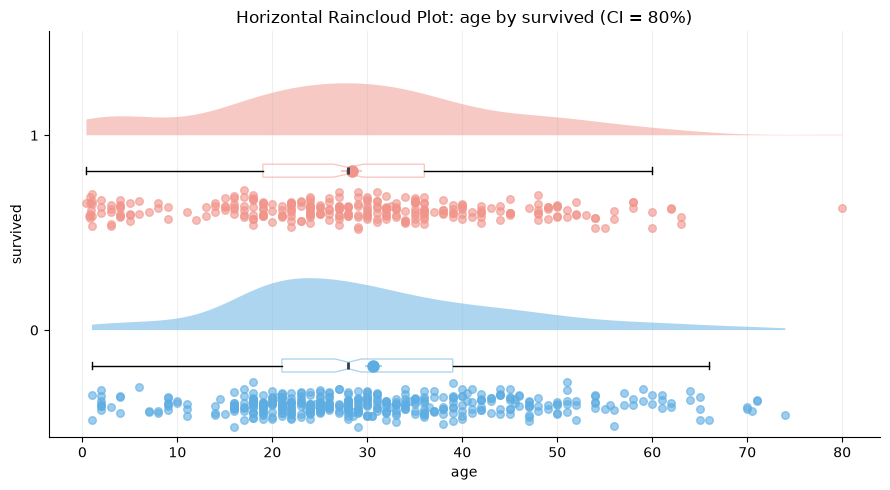

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.axes as mpl_axes
import scipy.stats
from typing import Tuple, Optional, Any

# ==============================================================================
# Класс Plotter: Управление фигурами и осями Matplotlib
# ==============================================================================

class Plotter:
    def __init__(self, nrows: int = 1, ncols: int = 1, figsize: Tuple[int, int] = (6, 6)) -> None:
        # --------------------------------------------------------
        # Инициализация фигуры и массива осей
        # --------------------------------------------------------
        self.fig, self.axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
        self.nrows = nrows
        self.ncols = ncols
        
        if nrows == 1 and ncols == 1:
            self.axes = np.array([self.axes])
        elif nrows == 1 or ncols == 1:
            self.axes = self.axes.reshape(-1)
        else:
            self.axes = self.axes.flatten()

        self.position = None
    
    def __getitem__(self, index: int):
        return self._get_axes_by_index(index)
    
    def __getattr__(self, name: str):
        if hasattr(mpl_axes.Axes, name):
            def dynamic_method(*args, 
                             idx: Optional[int] = None,
                             irow: Optional[int] = None,
                             icol: Optional[int] = None,
                             **kwargs):
                ax = self._get_axis(idx, irow, icol) if self.position is None else self.position
                method = getattr(ax, name)
                return method(*args, **kwargs)
            
            return dynamic_method
        
        raise AttributeError(f"'{type(self).__name__}' object has no attribute '{name}'")
    
    def _get_axes_by_index(self, idx: int = 0) -> Any:
        return self.axes[idx]
    
    def _get_axes_by_coords(self, irow: int = 0, icol: int = 0) -> Any:
        idx = irow * self.ncols + icol
        return self.axes[idx]

    def _get_axis(self,
                  idx: Optional[int] = None,
                  irow: Optional[int] = None,
                  icol: Optional[int] = None) -> Any:
        if idx is not None:
            return self._get_axes_by_index(idx)
        elif irow is not None and icol is not None:
            return self._get_axes_by_coords(irow, icol)
        else:
            return self.axes[0]
    
    def set_position(self,
                     idx: Optional[int] = None,
                     irow: Optional[int] = None,
                     icol: Optional[int] = None) -> None:
        self.position = self._get_axis(idx, irow, icol)
    
    def del_position(self) -> None:
        self.position = None
        
    def labels(self,
               xlabel: str,
               ylabel: str,
               title: str,
               idx: Optional[int] = None,
               irow: Optional[int] = None,
               icol: Optional[int] = None) -> Any:
        ax = self._get_axis(idx, irow, icol) if self.position is None else self.position
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        return ax

    def raincloud_plot(self, data, param_name, target_col_name, classes, colors,
                       idx: Optional[int] = None,
                       irow: Optional[int] = None,
                       icol: Optional[int] = None,
                       violin_width: float = 0.8,
                       violin_alpha: float = 0.5,
                       points_size: int = 30,
                       points_alpha: float = 0.6,
                       box_alpha: float = 0.5,
                       median_width: int = 2,
                       pixel_shift_y: float = -15,
                       jitter_extra_shift: float = -0.3,
                       class_spacing: float = 1.5,
                       top_padding: float = 0.8,
                       confidence_level: float = 0.95) -> Any:
        """
        Построение горизонтального raincloud plot для сравнения распределений
        числового параметра между несколькими классами.

        График объединяет в себе четыре визуальных компонента:
        - violin plot (половинка) — оценка плотности распределения;
        - scatter points (jitter) — отдельные наблюдения с вертикальным шумом;
        - boxplot — медиана, квартили и границы;
        - errorbar — доверительный интервал для среднего значения.

        Аргументы
        ---------
        data : pandas.DataFrame
            Исходная таблица данных.

        param_name : str
            Имя числового столбца, распределение которого анализируется.

        target_col_name : str
            Имя категориального столбца, по которому производится группировка.

        classes : list
            Список уникальных значений из target_col_name для отображения.
            Каждый класс получает отдельную горизонтальную полосу на графике.

        colors : list[str]
            Список цветов в формате HEX или RGB.
            Цвета назначаются классам циклически.

        idx : int | None, default=None
            Индекс оси в плоском массиве self.axes.
            Используется для выбора целевого subplot.

        irow : int | None, default=None
            Номер строки целевого subplot (используется вместе с icol).

        icol : int | None, default=None
            Номер столбца целевого subplot (используется вместе с irow).

        violin_width : float, default=0.8
            Ширина violin plot в координатах оси Y.
            Большие значения делают "облако" шире.

        violin_alpha : float, default=0.5
            Прозрачность заливки violin plot.
            Значения от 0 (полностью прозрачный) до 1 (непрозрачный).

        points_size : int, default=30
            Размер точек jitter в пунктах.

        points_alpha : float, default=0.6
            Прозрачность точек jitter.

        box_alpha : float, default=0.5
            Прозрачность заливки boxplot.

        median_width : int, default=2
            Толщина линии медианы в boxplot.

        pixel_shift_y : float, default=-15
            Точный вертикальный сдвиг jitter, boxplot и errorbar
            относительно violin plot, в пикселях.
            Отрицательные значения — сдвиг вниз.

        jitter_extra_shift : float, default=-0.3
            Дополнительное вертикальное смещение jitter
            в координатах оси Y (относительно boxplot и errorbar).
            Используется для визуального разделения слоев.

        class_spacing : float, default=1.5
            Расстояние между центрами соседних классов
            в координатах оси Y.
            Большие значения увеличивают пустое пространство между графиками.

        top_padding : float, default=0.8
            Дополнительное пространство сверху графика
            в координатах оси Y.

        confidence_level : float, default=0.95
            Уровень доверия для доверительного интервала среднего.
            Значение должно быть в диапазоне (0, 1).
            Примеры:
            - 0.90 — 90% доверительный интервал;
            - 0.95 — 95% доверительный интервал (стандарт);
            - 0.99 — 99% доверительный интервал.

        Возвращает
        ----------
        ax : matplotlib.axes.Axes
            Объект оси, на которой построен график.
        """

        # --------------------------------------------------------
        # Валидация входных параметров
        # --------------------------------------------------------
        if not 0 < confidence_level < 1:
            raise ValueError(
                "confidence_level должен быть строго в диапазоне (0, 1)."
            )

        ax = self._get_axis(idx, irow, icol) if self.position is None else self.position
        
        # --------------------------------------------------------
        # Шаг 0. Расчет точных границ оси Y для вмещения всех элементов
        # --------------------------------------------------------
        ax.set_ylim(-2.0, len(classes) * class_spacing + 2.0)
        self.fig.canvas.draw()
        
        bbox = ax.get_window_extent()
        y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
        pixels_per_unit = bbox.height / y_range
        shift_in_units = pixel_shift_y / pixels_per_unit
        
        y_min = 0 + shift_in_units + jitter_extra_shift - 0.25
        y_max = (len(classes) - 1) * class_spacing + top_padding
        
        ax.set_ylim(y_min, y_max)
        
        # --------------------------------------------------------
        # Шаг 1. Построение элементов raincloud plot для каждого класса
        # --------------------------------------------------------
        for i, group in enumerate(classes):
            local_data = data[data[target_col_name] == group][param_name]
            
            if len(local_data) == 0:
                continue
            
            position = i * class_spacing
                
            # 1.1. Violin plot (якорный элемент, остается на исходной позиции)
            violin_parts = ax.violinplot(local_data, positions=[position], vert=False,
                                         showextrema=False, showmedians=False, widths=violin_width)
                    
            for pc in violin_parts['bodies']:
                pc.set_facecolor(colors[i % len(colors)])
                pc.set_alpha(violin_alpha)
                vertices = pc.get_paths()[0].vertices
                vertices[:, 1] = np.clip(vertices[:, 1], position, np.inf)

            # 1.2. Jitter (точки) с комбинированным сдвигом вниз
            y_points = np.random.normal(position + shift_in_units + jitter_extra_shift, 0.06, len(local_data))
            ax.scatter(local_data, y_points, alpha=points_alpha, s=points_size, 
                       color=colors[i % len(colors)])
            
            # 1.3. Доверительный интервал для среднего со сдвигом вниз
            # Уровень доверия задается параметром confidence_level
            mean = np.mean(local_data)
            sem = scipy.stats.sem(local_data)
            alpha_tail = (1 - confidence_level) / 2
            ci_low, ci_high = scipy.stats.t.interval(
                confidence_level, len(local_data) - 1, loc=mean, scale=sem
            )
            
            ax.errorbar(mean, position + shift_in_units, xerr=[[mean-ci_low], [ci_high-mean]], 
                        fmt='o', color=colors[i % len(colors)], markersize=8)

            # 1.4. Boxplot со сдвигом вниз
            boxplots = ax.boxplot(local_data, positions=[position + shift_in_units], widths=0.1, 
                                  notch=True, patch_artist=True, showfliers=False, vert=False)

            for box in boxplots['boxes']:
                box.set_facecolor('white')
                box.set_alpha(box_alpha)
                box.set_edgecolor(colors[i % len(colors)])
            for median in boxplots['medians']:
                median.set_color('#2C3E50')
                median.set_linewidth(median_width)
        
        # --------------------------------------------------------
        # Шаг 2. Настройка визуального стиля (UpSet style)
        # --------------------------------------------------------
        ax.set_yticks([i * class_spacing for i in range(len(classes))])
        ax.set_yticklabels(classes)
        ax.set_xlabel(param_name)
        ax.set_ylabel(target_col_name)
        ax.set_title(
            f'Horizontal Raincloud Plot: {param_name} by {target_col_name} '
            f'(CI = {int(confidence_level * 100)}%)'
        )
        
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis='x', alpha=0.20)
        
        return ax

    def tight_layout(self) -> None:
        self.fig.tight_layout()
    
    def save(self, path: str, dpi: int = 300, **kwargs) -> None:
        self.fig.savefig(path, dpi=dpi, **kwargs)
    
    def show(self) -> None:
        plt.show()


# ==============================================================================
# Шаг 1. Загрузка и очистка данных
# ==============================================================================

file_path = "/home/julia/code/NSU_AI-Robotics/tsr/archive/Titanic.csv"
df = pd.read_csv(file_path)

df = df.loc[:, ~df.columns.str.contains('^Unnamed')]


# ==============================================================================
# Шаг 2. Интеллектуальный выбор столбцов (регистронезависимый)
# ==============================================================================

cols_lower = {col.lower(): col for col in df.columns}

numeric_cols = df.select_dtypes(include='number').columns.tolist()
param_name = cols_lower.get('age', cols_lower.get('fare', numeric_cols[0] if numeric_cols else df.columns[0]))

categorical_cols = df.select_dtypes(exclude='number').columns.tolist()
target_col_name = cols_lower.get('survived', cols_lower.get('sex', cols_lower.get('class', categorical_cols[0] if categorical_cols else df.columns[0])))

print(f"Доступные столбцы: {df.columns.tolist()}")
print(f"Автоматически выбраны: параметр='{param_name}', цель='{target_col_name}'")

df_clean = df.dropna(subset=[param_name, target_col_name]).copy()


# ==============================================================================
# Шаг 3. Определение цветовой палитры и классов
# ==============================================================================

primary_color = "#5DADE2"   # Прозрачно-голубой
secondary_color = "#F1948A" # Прозрачно-красный
plot_colors = [primary_color, secondary_color]

classes = sorted(df_clean[target_col_name].unique().tolist())

if len(classes) > 3:
    classes = classes[:3]
    df_clean = df_clean[df_clean[target_col_name].isin(classes)].copy()
    print(f"Внимание: количество классов ограничено первыми 3: {classes}")


# ==============================================================================
# Шаг 4. Инициализация и построение графика
# ==============================================================================

plotter = Plotter(nrows=1, ncols=1, figsize=(9, 5))

plotter.raincloud_plot(
    data=df_clean,
    param_name=param_name,
    target_col_name=target_col_name,
    classes=classes,
    colors=plot_colors,
    violin_alpha=0.5,
    points_alpha=0.6,
    box_alpha=0.5,
    pixel_shift_y=-15,         # Сдвиг элементов вниз на 15 пикселей относительно позиции violin
    jitter_extra_shift=-0.3,   # Дополнительное отклонение jitter вниз
    class_spacing=1.5,         # Расстояние между классами
    top_padding=0.8,           # Пространство сверху
    confidence_level=0.8      
)

plotter.tight_layout()
plotter.show()